#### [자동차 연비 관련 분석] <hr>
- 데이터: auto_mpg.csv
- 특징:
    - 1993년도 미국에 자동차 연비 분석을 위해 수집된 데이터
    - 9개 컬럼/ 변수 (1개 타깃, 8개 핏쳐)
    - 다변량 데이터셋
---

### [1] 모듈 로딩 및 데이터 준비 <hr>

In [4]:
## 모듈 로딩
import pandas as pd

In [1]:
DATA_FILE= '../Data/auto_mpg.csv'


### [2] CS=> DataFrame 로딩 및 기본 정보 확인 <hr>

In [6]:
## DF 인스턴스 생성
# -> header=0, sep=',' 이 기본값
mpgDF= pd.read_csv(DATA_FILE)

In [13]:
## 정보 확인



print(mpgDF.dtypes)
mpgDF.head(3)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite


In [15]:
## 모든 컬럼의 기초 통계값 확인=> describe()
mpgDF.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,398,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,NaN,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,NaN,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,NaN,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,NaN,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,NaN,3608.000000,17.175000,79.000000,2.000000,NaN


### [3] 기초 전처리 <hr>

- 결측치/ 중복값 체크
- 컬럼별 자료형 일치

In [16]:
## [3-1] 결측치: isnull(), isna()

mpgDF.isnull()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
393,False,False,False,False,False,False,False,False,False
394,False,False,False,False,False,False,False,False,False
395,False,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False,False


In [ ]:
## [3-3] 컬럼별 자료형 변환
## => horsepower 컬럼 object>>> int

mpgDF
mpgDF['horsepower'].value_counts()['?']

np.int64(6)

In [33]:
drop_index=mpgDF[mpgDF['horsepower']=='?'].index
mpgDF= mpgDF.drop(index=drop_index).reset_index(drop=True)

# object >>> int 형변환하기
mpgDF['horsepower']= mpgDF['horsepower'].astype(int)


In [29]:
## [3-3] 컬럼별 자료형 변환- model_year, cylinder, origin 컬럼
## model_year, cylinders, origin int 64>>> 범주형
## 고유값 확인 즉, 컬럼별 값의 종류 체크


for col in ['model year', 'cylinders', 'origin']:
    print(f'{col:10}===> {mpgDF[col].unique()}')
# mpgDF.cylinders.nunique()

model year===> [70 71 72 73 74 75 76 77 78 79 80 81 82]
cylinders ===> [8 4 6 3 5]
origin    ===> [1 3 2]


In [31]:
## int >>> 범주형 형변환

for col in ['model year', 'cylinders', 'origin']:
    mpgDF[col]=mpgDF[col].astype('category')

In [34]:
mpgDF.dtypes

mpg              float64
cylinders       category
displacement     float64
horsepower         int64
weight             int64
acceleration     float64
model year      category
origin          category
car name          object
dtype: object

[4] 연비 MPG 컬럼과 관련성이 있는 속성/ 피쳐 <HR>

- 타겟 컬럼/ 속성: mpg
- 피처 컬럼/ 변수: 나머지 컬럼들
- 상관계수 활용
    - 컬럼들의 관계(선형) 정도를 수치화
    - 값의 범위: -1 ~ +1
    - 인과관계 아님
    - 완벽한 선형이 아닌 경우 값이 -1~1 에 가까운 값이 안 나올수도 있음
    - 시각화를 통해 컬럼들을 결정지어야 됨

In [35]:
## mpg 컬럼만 추출
mpgDF.corr(numeric_only=True)['mpg'].abs()

mpg             1.000000
displacement    0.805127
horsepower      0.778427
weight          0.832244
acceleration    0.423329
Name: mpg, dtype: float64

In [38]:
## [3-4] 컬럼 별 자료형 변환- 연속형/ 수치형>>> 범주형
## - 숫자 값을 일정 구간으로 나누어서 이해가 쉽도록 만들어주는 방법
## 예) 연령대: 1, 3, 5, 33==> 10대, 20대, 30대===> 청년, 중년, 장년, 노년
# pandas.cut()
## 마력/ 출력: 저출력, 일반 출력, 고출력

retSR= pd.cut(x=mpgDF['horsepower'], bins=3, labels=['저출력', '일반출력', '고출력'])

##현재 데이터 프레임에 새컬럼으로 추가
mpgDF['horsepower_label']=retSR

mpgDF.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,horsepower_label
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,일반출력
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,일반출력
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,일반출력


<Axes: >

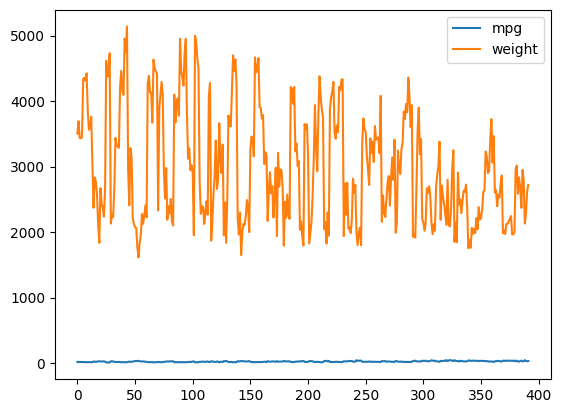

In [39]:
### mpg 컬럼과 다른 컬럼과의 관계 시각화
mpgDF[['mpg', 'weight']].plot()

<Axes: xlabel='mpg', ylabel='weight'>

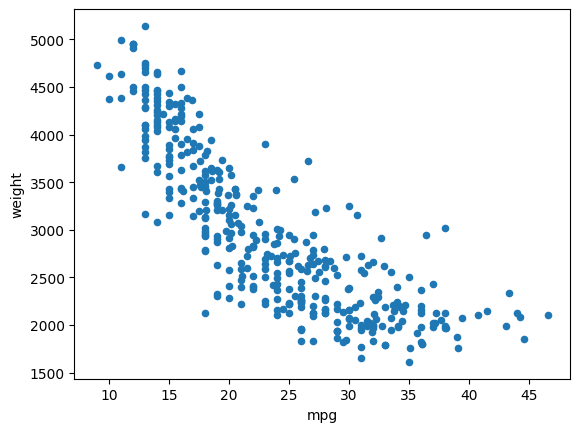

In [40]:
mpgDF.plot(x='mpg', y='weight', kind='scatter')

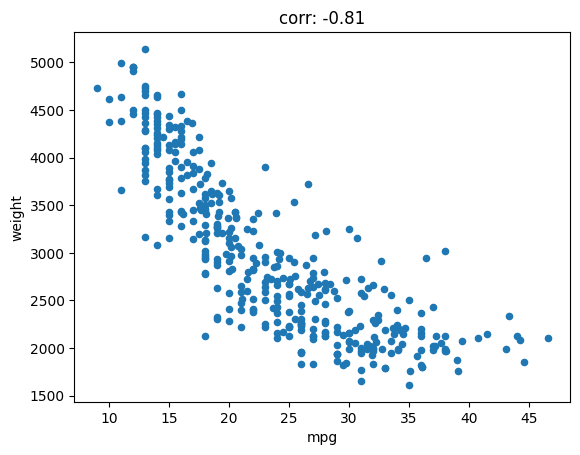

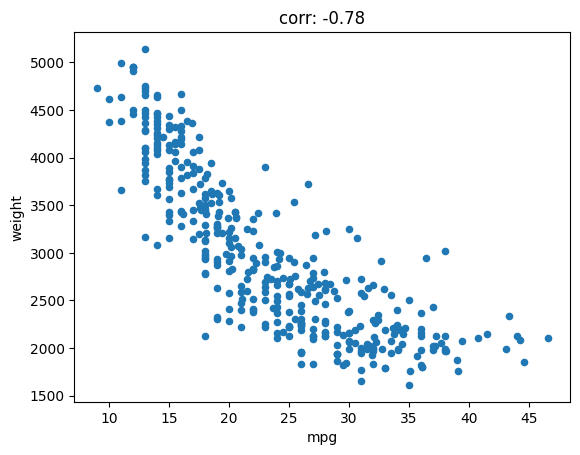

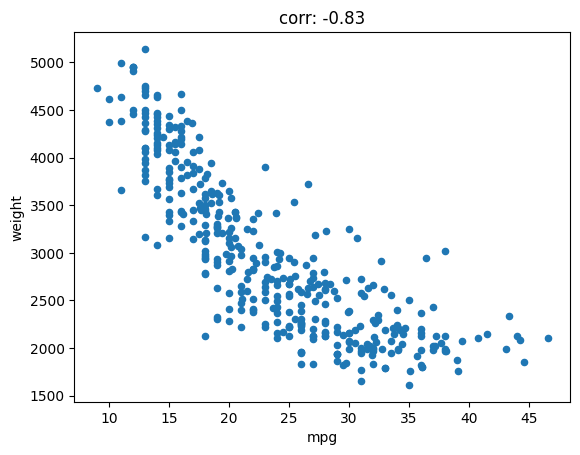

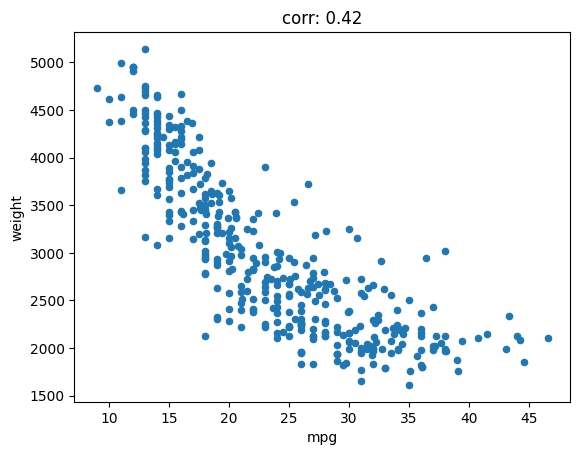

In [45]:
corrSR=mpgDF.corr(numeric_only=True)['mpg']
corrSR.index[1:]

for col in corrSR.index[1:]:
    mpgDF.plot(x='mpg', y='weight', kind='scatter', title=f'corr: {corrSR[col]:.2f}')